**Project Introduction**


In recent years, several companies worldwide have conducted major layoffs due to economic uncertainty, market corrections, and changes in funding environments.
This project analyzes global layoffs to identify patterns across companies, industries, countries, and startup funding stages.

**Problem Statement**

 
The objective of this project is to analyze global layoffs data and uncover insights about which industries, countries, and companies were most affected, along with trends in layoffs over time.   

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)   # medium size for all charts

In [2]:
df = pd.read_csv("data/layoffs_raw.csv")
df.head()

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Atlassian,Sydney,Other,500.0,0.05,3/6/2023,Post-IPO,Australia,210.0
1,SiriusXM,New York City,Media,475.0,0.08,3/6/2023,Post-IPO,United States,525.0
2,Alerzo,Ibadan,Retail,400.0,NaN,3/6/2023,Series B,Nigeria,16.0
3,UpGrad,Mumbai,Education,120.0,NaN,3/6/2023,Unknown,India,631.0
4,Loft,Sao Paulo,Real Estate,340.0,0.15,3/3/2023,Unknown,Brazil,788.0


In [3]:
df.shape

(2361, 9)

In [4]:
df.columns

Index(['company', 'location', 'industry', 'total_laid_off',
       'percentage_laid_off', 'date', 'stage', 'country',
       'funds_raised_millions'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                2361 non-null   object 
 1   location               2361 non-null   object 
 2   industry               2357 non-null   object 
 3   total_laid_off         1621 non-null   float64
 4   percentage_laid_off    1576 non-null   float64
 5   date                   2360 non-null   object 
 6   stage                  2355 non-null   object 
 7   country                2361 non-null   object 
 8   funds_raised_millions  2152 non-null   float64
dtypes: float64(3), object(6)
memory usage: 166.1+ KB


In [6]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised_millions
count,1621.000000,1576.000000,2152.000000
mean,238.358421,0.257917,822.454134
std,769.718801,0.255575,5593.961626
min,3.000000,0.000000,0.000000
25%,36.000000,0.100000,50.000000
50%,80.000000,0.170000,156.500000
75%,180.000000,0.300000,445.000000
max,12000.000000,1.000000,121900.000000


In [7]:
df.isnull().sum()

company                    0
location                   0
industry                   4
total_laid_off           740
percentage_laid_off      785
date                       1
stage                      6
country                    0
funds_raised_millions    209
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df = df.dropna(subset=['total_laid_off'])

In [11]:
df['industry'] = df['industry'].str.strip()

In [12]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [13]:
df.head()

,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions,year,month
0,Atlassian,Sydney,Other,500.0,0.05,2023-03-06,Post-IPO,Australia,210.0,2023.0,3.0
1,SiriusXM,New York City,Media,475.0,0.08,2023-03-06,Post-IPO,United States,525.0,2023.0,3.0
2,Alerzo,Ibadan,Retail,400.0,NaN,2023-03-06,Series B,Nigeria,16.0,2023.0,3.0
3,UpGrad,Mumbai,Education,120.0,NaN,2023-03-06,Unknown,India,631.0,2023.0,3.0
4,Loft,Sao Paulo,Real Estate,340.0,0.15,2023-03-03,Unknown,Brazil,788.0,2023.0,3.0


**EDA (Exploratory Data Analysis)**

1️⃣ Top 10 Companies with Highest Layoffs

/tmp/ipykernel_2296/287156545.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.index, y=top_companies.values, palette="Reds_r")


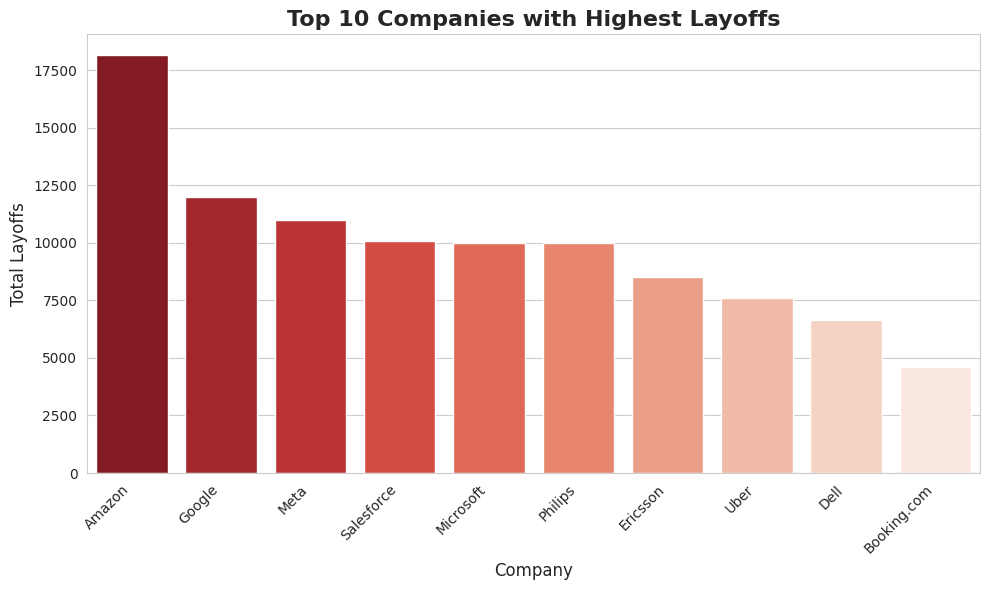

In [14]:
top_companies = df.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_companies.index, y=top_companies.values, palette="Reds_r")

plt.title("Top 10 Companies with Highest Layoffs", fontsize=16, fontweight="bold")
plt.xlabel("Company", fontsize=12)
plt.ylabel("Total Layoffs", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Insight
Amazon leads layoffs by a wide margin, followed by Google and Meta, showing that workforce cuts are concentrated among the largest tech firms.


2️⃣ Layoffs by Industry

/tmp/ipykernel_2296/200393866.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_layoffs.index, y=industry_layoffs.values, palette="viridis")


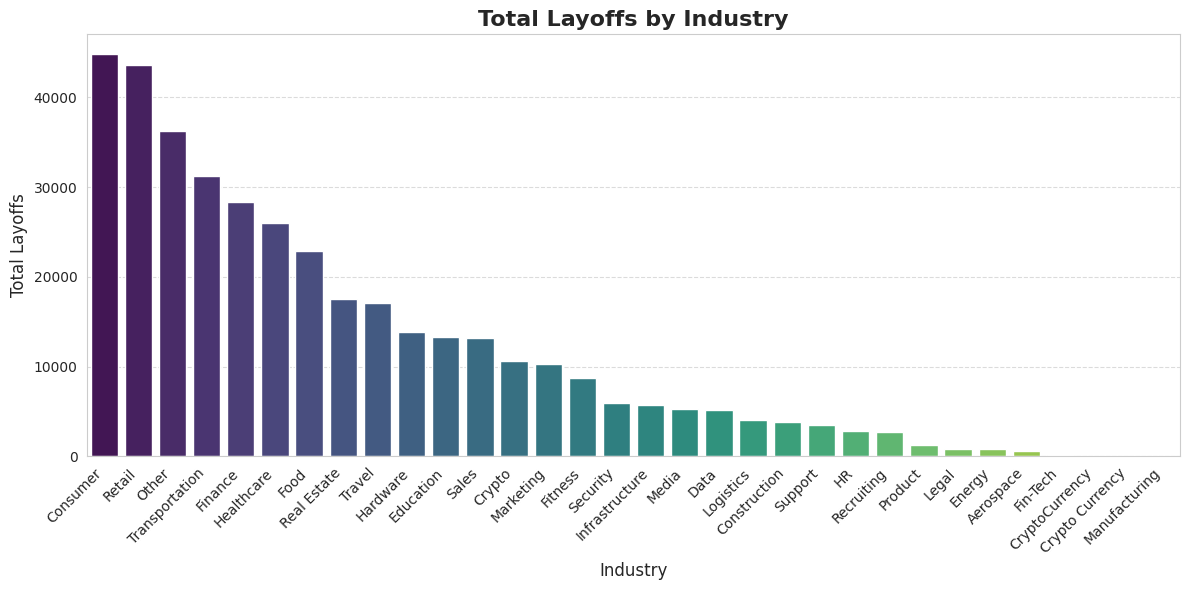

In [15]:
# Industry layoffs data
industry_layoffs = df.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))  # bigger figure for clarity
sns.barplot(x=industry_layoffs.index, y=industry_layoffs.values, palette="viridis")

# Titles and labels
plt.title("Total Layoffs by Industry", fontsize=16, fontweight="bold")
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Total Layoffs", fontsize=12)

# Rotate labels for readability
plt.xticks(rotation=45, ha="right")

# Add gridlines for neatness
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Insight
Consumer and retail industries have the most layoffs, while manufacturing and energy are least affected.


3️⃣ Average Layoff Size per Industry

/tmp/ipykernel_2296/3353581850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


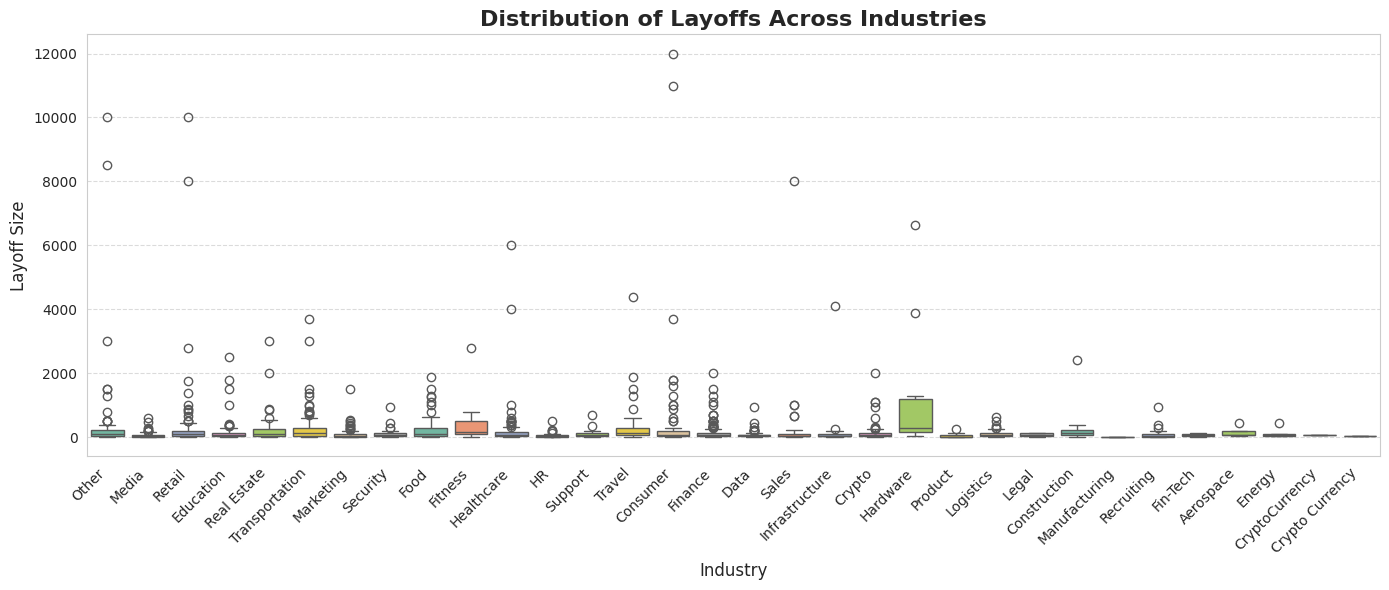

In [16]:

plt.figure(figsize=(14,6))  # wider figure for readability

sns.boxplot(
    x='industry', 
    y='total_laid_off', 
    data=df, 
    palette="Set2"   # softer, professional colors
)

# Titles and labels
plt.title("Distribution of Layoffs Across Industries", fontsize=16, fontweight="bold")
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Layoff Size", fontsize=12)

# Rotate labels neatly
plt.xticks(rotation=45, ha="right")

# Add gridlines for clarity
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


### Insight
Some industries face very large layoffs, while others have smaller ones. Retail and transportation show bigger cuts compared to manufacturing or energy.


4️⃣ Top Countries with Most Layoffs

/tmp/ipykernel_2296/1846974257.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_layoffs.index, y=country_layoffs.values, palette="magma")


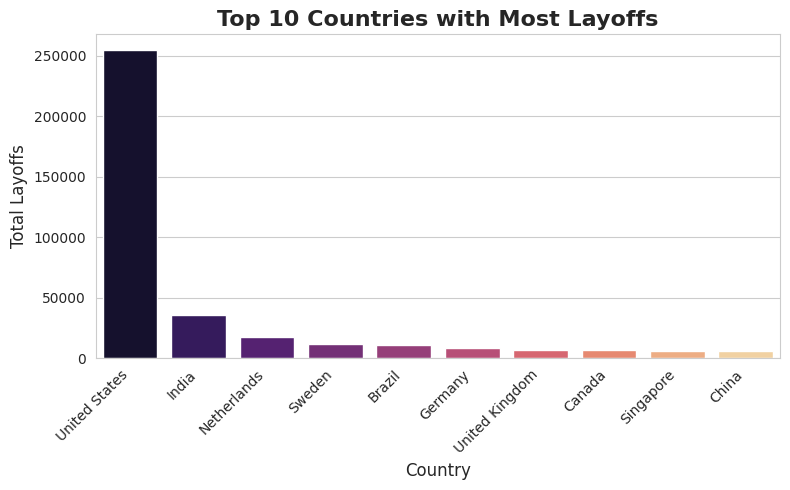

In [17]:
country_layoffs = df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=country_layoffs.index, y=country_layoffs.values, palette="magma")

plt.title("Top 10 Countries with Most Layoffs", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Layoffs", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Insight
Most layoffs happened in the United States, with India second. Other countries had far fewer layoffs.


5️⃣ Top Locations (Cities) with Layoffs

/tmp/ipykernel_2296/3962649906.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_layoffs.index, y=location_layoffs.values, palette="cubehelix")


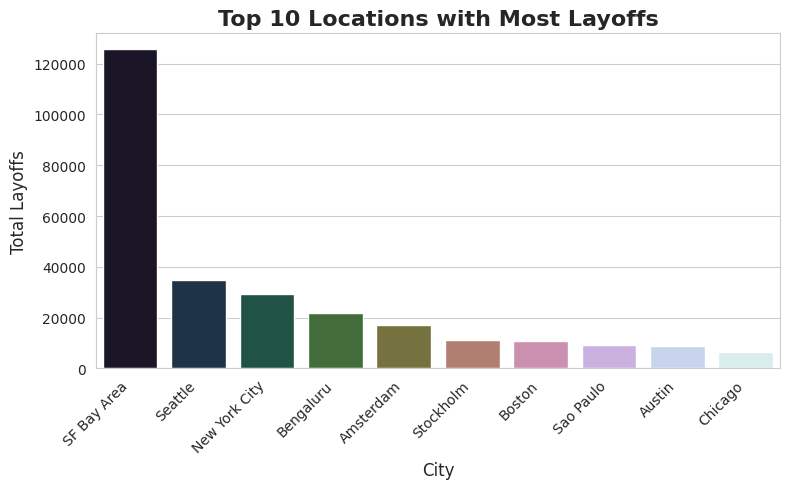

In [18]:
location_layoffs = df.groupby('location')['total_laid_off'].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=location_layoffs.index, y=location_layoffs.values, palette="cubehelix")

plt.title("Top 10 Locations with Most Layoffs", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize = 12)
plt.ylabel("Total Layoffs", fontsize = 12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Insight
SF Bay Area has the most layoffs, far more than other cities. Seattle and New York follow, while other locations show smaller numbers.


6️⃣ Layoffs Trend Over Time

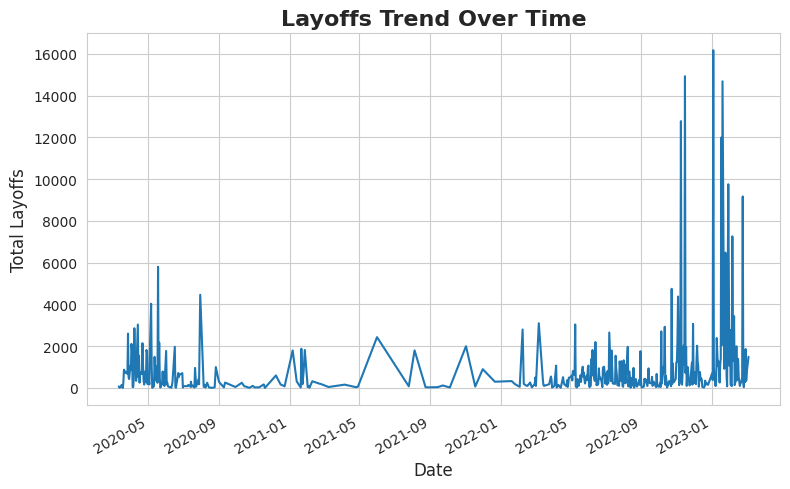

In [19]:
time_trend = df.groupby('date')['total_laid_off'].sum()

plt.figure()
time_trend.plot()

plt.title("Layoffs Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Total Layoffs", fontsize = 12)

plt.tight_layout()
plt.show()

### Insight
Layoffs increased sharply in late 2022 and early 2023, showing the biggest spikes during this period.


7️⃣ Layoffs By Year

/tmp/ipykernel_2296/2165768066.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_layoffs.index, y=year_layoffs.values, palette="Blues")


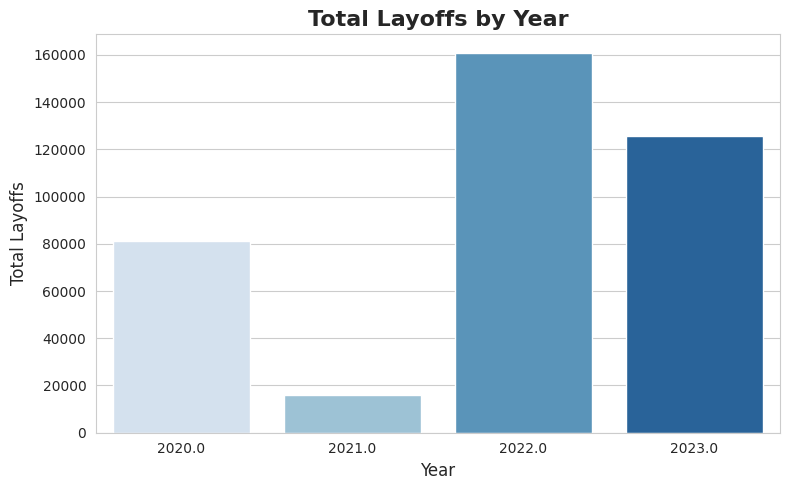

In [20]:
year_layoffs = df.groupby('year')['total_laid_off'].sum()

plt.figure()
sns.barplot(x=year_layoffs.index, y=year_layoffs.values, palette="Blues")

plt.title("Total Layoffs by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize = 12)
plt.ylabel("Total Layoffs", fontsize = 12)

plt.tight_layout()
plt.show()

### Insight
Layoffs were highest in 2022, followed by 2023. The lowest layoffs happened in 2021.


8️⃣ Layoff Percentage Distribution

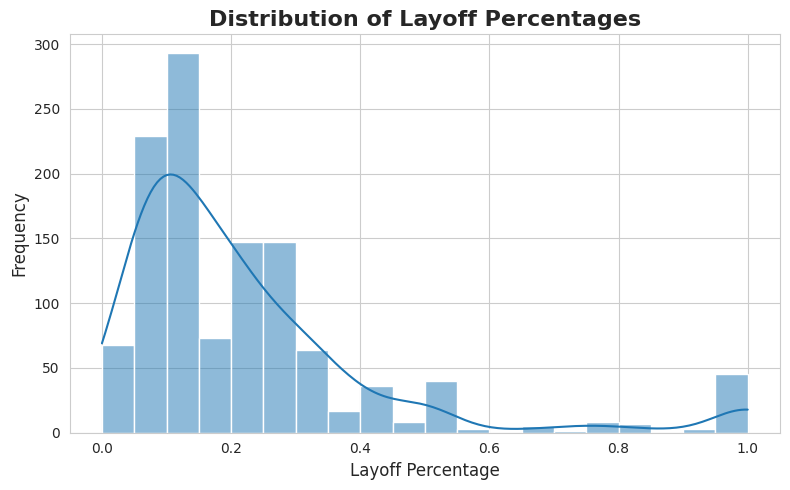

In [21]:
plt.figure()
sns.histplot(df['percentage_laid_off'], bins=20, kde=True)

plt.title("Distribution of Layoff Percentages", fontsize=16, fontweight="bold")
plt.xlabel("Layoff Percentage", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

### Insight
Most layoffs are small, around 10–15%. Very few companies cut 100% of staff.


9️⃣ Layoffs by Funding Stage

/tmp/ipykernel_2296/1104699738.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stage_layoffs.index, y=stage_layoffs.values, palette="Set2")


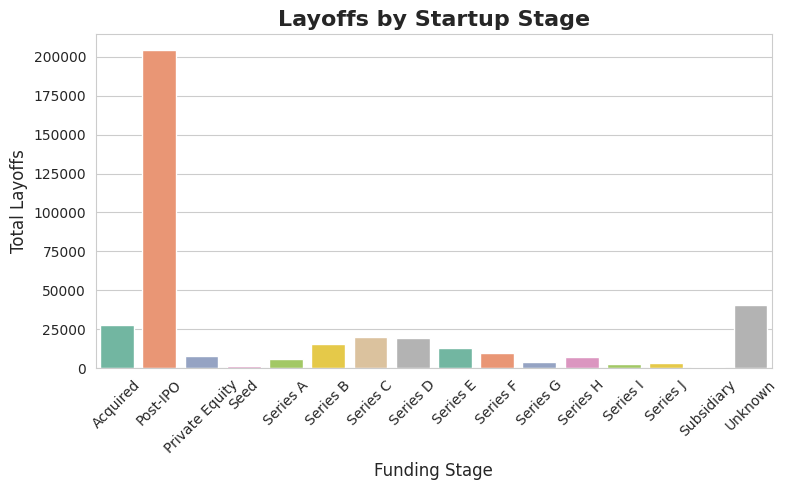

In [22]:
stage_layoffs = df.groupby('stage')['total_laid_off'].sum()

plt.figure()
sns.barplot(x=stage_layoffs.index, y=stage_layoffs.values, palette="Set2")

plt.title("Layoffs by Startup Stage", fontsize=16, fontweight="bold")
plt.xlabel("Funding Stage", fontsize=12)
plt.ylabel("Total Layoffs", fontsize=12)
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

### Insight
Most layoffs happened in startups at the Post-IPO stage, while early-stage startups like Seed or Series A had very few.


🔟 Funding Raised vs Layoffs

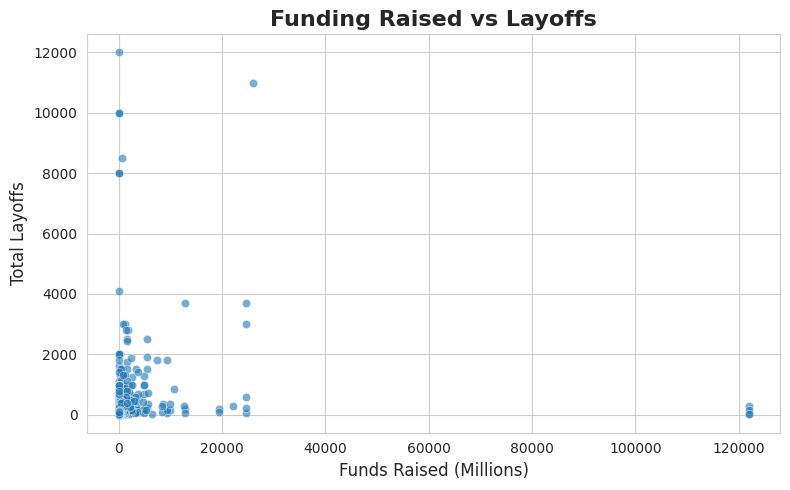

In [23]:
plt.figure()
sns.scatterplot(
    data=df,
    x='funds_raised_millions',
    y='total_laid_off',
    alpha=0.6
)

plt.title("Funding Raised vs Layoffs", fontsize=16, fontweight="bold")
plt.xlabel("Funds Raised (Millions)", fontsize=12)
plt.ylabel("Total Layoffs", fontsize=12)

plt.tight_layout()
plt.show()

### Insight
Most companies with low funding had small layoffs. A few outliers show very high funding or very high layoffs, but no clear link between the two.


1️⃣1️⃣ Industry vs Country Layoffs

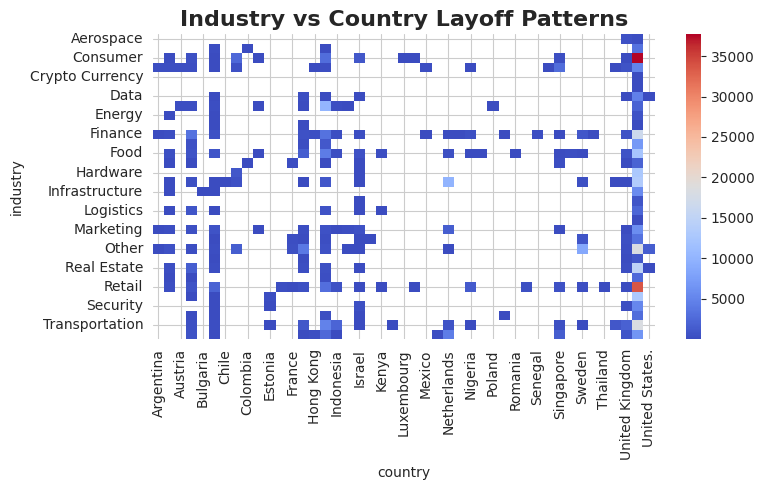

In [24]:
pivot = df.pivot_table(
    values='total_laid_off',
    index='industry',
    columns='country',
    aggfunc='sum'
)

plt.figure()
sns.heatmap(pivot, cmap="coolwarm")

plt.title("Industry vs Country Layoff Patterns", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Insight
The United States shows the highest layoffs across many industries, while most other countries have much lower numbers.


In [25]:
df.to_csv("cleaned_layoffs_dataset.csv", index=False)

**📊 Final Summary & Key Takeaways**

After analyzing the global layoffs dataset, several meaningful patterns emerge across companies, industries, regions, and funding stages.

🔹 Company Impact:
A small number of companies account for a large share of total layoffs, indicating that major organizational restructuring by large firms significantly influences overall workforce reductions.

🔹 Industry Trends:
Certain industries experienced substantially higher layoffs compared to others, suggesting that economic pressures and market slowdowns affect sectors differently.

🔹 Geographical Concentration:
Layoffs are heavily concentrated in specific countries and cities that host major startup and technology ecosystems. This highlights the strong regional concentration of the global tech workforce.

🔹 Time-Based Trends:
The analysis shows that layoffs occur in waves rather than steadily over time, reflecting broader economic cycles and changes in funding environments.

🔹 Funding & Startup Stages:
Interestingly, companies that raised significant funding and those in later startup stages also conducted notable layoffs. This indicates that high capital availability does not necessarily guarantee workforce stability.

**💡 Overall Insight**

Overall, global layoffs appear to be driven by a combination of industry dynamics, regional startup ecosystems, funding strategies, and macroeconomic conditions. Understanding these patterns can help companies adopt more sustainable hiring strategies and better prepare for future economic fluctuations.